In [39]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,ConfusionMatrixDisplay,roc_auc_score,roc_curve
import matplotlib.pyplot as plt

# Loading the dataset

In [40]:
credit_df = pd.read_csv("german_credit_data.csv")
credit_df.head(15)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
5,35,male,1,free,NaN,NaN,9055,36,education,good
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
7,35,male,3,rent,little,moderate,6948,36,car,good
8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
9,28,male,3,own,little,moderate,5234,30,car,bad


# Handling the missing values

In [41]:
credit_df = credit_df.fillna("none")

# Encoding the target variable

In [42]:
label_enc = LabelEncoder()
credit_df["risk_encoded"] = label_enc.fit_transform(credit_df["Risk"])
credit_df.drop(columns="Risk",inplace=True)

In [43]:
X = credit_df.drop("risk_encoded",axis=1)
y = credit_df["risk_encoded"]

# Encoding the input features

In [44]:
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()
numeric_features = X.select_dtypes(include=["number"]).columns.to_list()
if "Job" in numeric_features:
    numeric_features.remove("Job")
print(numeric_features)


['Age', 'Credit amount', 'Duration']


# Dividing the categorical features into nominal and ordinal features

In [45]:
ordinal_features = ["Saving accounts","Checking account","Job"]
nominal_features = [col for col in categorical_features if col not in ordinal_features]
print(ordinal_features,nominal_features)

['Saving accounts', 'Checking account', 'Job'] ['Sex', 'Housing', 'Purpose']


# Defining the order of the categories

In [46]:
saving_order = ["none","little","moderate","quite rich","rich"]
checking_order = ["none","little","moderate","rich"]
job_order = [0,1,2,3]

explicit_cat = [saving_order,checking_order,job_order]

preprocessor = ColumnTransformer(
    transformers=[("num","passthrough",numeric_features),
                  ("ord",OrdinalEncoder(categories=explicit_cat,handle_unknown="use_encoded_value",unknown_value=-1),ordinal_features),
                  ("nom",OneHotEncoder(handle_unknown="ignore"),nominal_features)]
)

# Splitting the dataset into training and testing sets

In [47]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [48]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_encoded,columns=feature_names)
X_train_df.head()

,num__Age,num__Credit amount,num__Duration,ord__Saving accounts,ord__Checking account,ord__Job,nom__Sex_female,nom__Sex_male,nom__Housing_free,nom__Housing_own,nom__Housing_rent,nom__Purpose_business,nom__Purpose_car,nom__Purpose_domestic appliances,nom__Purpose_education,nom__Purpose_furniture/equipment,nom__Purpose_radio/TV,nom__Purpose_repairs,nom__Purpose_vacation/others
0,26.0,4530.0,30.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,41.0,2503.0,30.0,2.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,22.0,1567.0,12.0,1.0,2.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,35.0,3976.0,21.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,22.0,2301.0,9.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


# Performing feature selection from the encoded features

In [49]:
baseline_rf = RandomForestClassifier(n_estimators=50,random_state=42,class_weight="balanced")
selector = SelectFromModel(baseline_rf,threshold="median")
X_train_selected = selector.fit_transform(X_train_encoded,y_train)
X_test_selected = selector.transform(X_test_encoded)
print(f"Training dataset shape:{X_train_selected.shape}")
print(f"Test data set shape: {X_test_selected.shape}")

Training dataset shape:(800, 10)
Test data set shape: (200, 10)


In [50]:
selected_features = feature_names[selector.get_support()]
print(selected_features)

['num__Age' 'num__Credit amount' 'num__Duration' 'ord__Saving accounts'
 'ord__Checking account' 'ord__Job' 'nom__Sex_female' 'nom__Housing_own'
 'nom__Purpose_car' 'nom__Purpose_radio/TV']


In [51]:
final_rf = RandomForestClassifier(n_estimators=50,random_state=42,class_weight="balanced")
final_rf.fit(X_train_selected,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

# Evaluating the model on the test dataset

In [52]:
y_pred = final_rf.predict(X_test_selected)
print(y_pred)

[1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 0 1 0 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1
 1 0 0 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 1 1 0 1
 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1]


# Creating the confusion matrix

In [53]:
conf_mat = confusion_matrix(y_test,y_pred)
print(conf_mat)

[[ 25  35]
 [ 16 124]]


# Plotting the confusion matrix

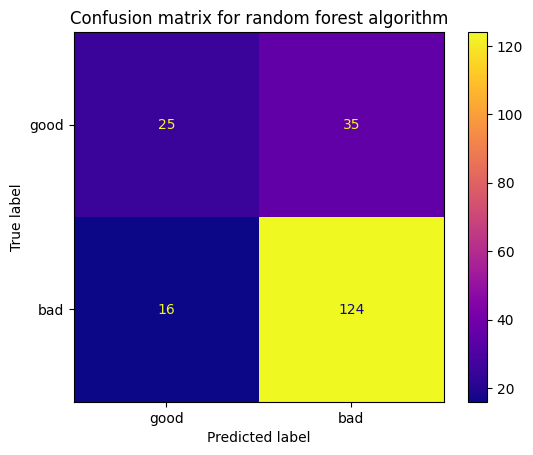

In [54]:
disp = ConfusionMatrixDisplay(conf_mat,display_labels=["good","bad"])
disp.plot(cmap=plt.cm.plasma)
plt.title("Confusion matrix for random forest algorithm")
plt.show()

In [55]:
y_probs = final_rf.predict_proba(X_test_selected)[:,1]
model_accuracy = accuracy_score(y_test,y_pred)
auc_score = roc_auc_score(y_test,y_probs)
print("Accuracy: ",model_accuracy)
print("ROC - AUC score",auc_score)

Accuracy:  0.745
ROC - AUC score 0.7443452380952382


# Plotting the `ROC` curve

In [56]:
fpr,tpr,thresholds = roc_curve(y_test,y_probs)

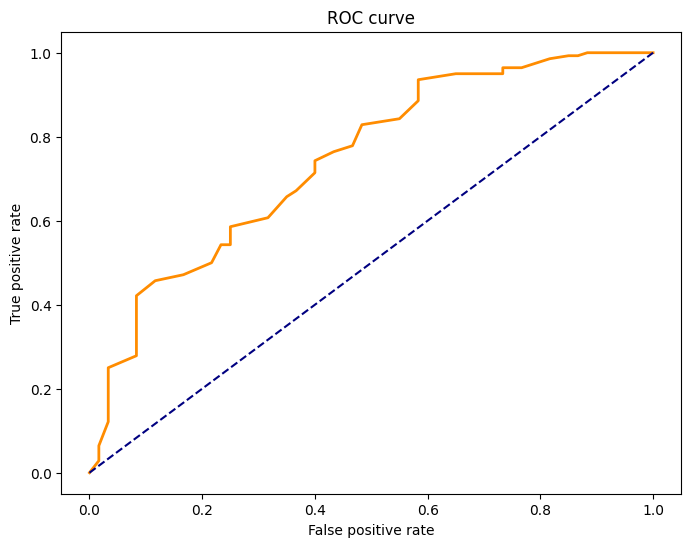

In [57]:
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color="darkorange",linewidth=2,label=f"Random forest (AUC = {auc_score:.3f})")
plt.plot([0,1],[0,1],color="navy",linestyle="dashed",label=f"Random gues (AUC: 0.5)")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.show()